In [135]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, roc_curve, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text 
from sklearn.inspection import permutation_importance
import json 
from datetime import datetime
import joblib
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [124]:
df = pd.read_csv('./data/S06-hw-dataset-02.csv')
print("\nПервые строки датасета (head):\n", df.head())
print("\nИнформация о столбцах и типах (info):\n")
df.info()

print("Проверка столбцов на пропуски:\n")
df.isna().mean()

print("Типы данных столбцов:\n")
print(df.dtypes)

target_counts = df['target'].value_counts()
print(target_counts)
print("Доли классов:")
print(target_counts / len(df) * 100)

print(f"Количество признаков: {X.shape[1]}")
print(f"Имена признаков: {list(X.columns)}")



Первые строки датасета (head):
    id       f01       f02       f03  ...        f35    x_int_1    x_int_2  target
0   1 -0.149235 -2.826966 -0.522901  ...   1.412751   0.421883   9.217167       1
1   2 -1.966180 -4.877542  0.268367  ...  -2.488690   9.590124  24.772826       0
2   3 -0.555964 -0.999920  0.209673  ...  -0.439798   0.555919  41.800517       0
3   4 -2.049199 -5.600713 -1.664677  ... -10.744916  11.476977  65.315860       0
4   5 -0.220556  4.889479 -2.235840  ...  -9.364106  -1.078404  93.017870       0

[5 rows x 39 columns]

Информация о столбцах и типах (info):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 39 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       18000 non-null  int64  
 1   f01      18000 non-null  float64
 2   f02      18000 non-null  float64
 3   f03      18000 non-null  float64
 4   f04      18000 non-null  float64
 5   f05      18000 non-null  float64

In [122]:
#Выделяем Х признаки и y таргет
X = df[[x for x in df.columns if not 'id' in x and not 'target' in x]]
y = df['target']
print(X, y)

            f01       f02       f03  ...        f35    x_int_1     x_int_2
0     -0.149235 -2.826966 -0.522901  ...   1.412751   0.421883    9.217167
1     -1.966180 -4.877542  0.268367  ...  -2.488690   9.590124   24.772826
2     -0.555964 -0.999920  0.209673  ...  -0.439798   0.555919   41.800517
3     -2.049199 -5.600713 -1.664677  ... -10.744916  11.476977   65.315860
4     -0.220556  4.889479 -2.235840  ...  -9.364106  -1.078404   93.017870
...         ...       ...       ...  ...        ...        ...         ...
17995 -1.920557 -1.422719 -1.031828  ...  -2.584146   2.732414    4.528493
17996 -1.914101 -2.124938  1.216011  ...  -1.203823   4.067347  105.359894
17997 -1.846604  7.583639 -1.107318  ...  -0.067665 -14.003977   12.202548
17998  1.742157  1.722399 -0.849028  ...   3.629549   3.000691   28.088015
17999 -2.157094  1.365535  0.365606  ...   2.663348  -2.945586    1.379511

[18000 rows x 37 columns] 0        1
1        0
2        0
3        0
4        0
        ..
17995  

In [126]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Размер train: {X_train.shape}")
print(f"Размер test: {X_test.shape}")

Размер train: (13500, 37)
Размер test: (4500, 37)


## Краткое пояснение почему важны `random_state` и `stratify`

- `random_state`: Важно для того, чтобы результат был воспроизводимым 

- `stratify`: сохраняет доли классов в обоих выборках

In [93]:
# делаю два baseline'а

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Dummy stratified
dummy_strat = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)

dummy_strat.fit(X_train, y_train)



y_pred_dm = dummy_strat.predict(X_test)
y_proba_dm = dummy_strat.predict_proba(X_test)[:, 1]

# Logistic Regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=4000, random_state=RANDOM_STATE))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

def calculate_metrics(y_test, y_pred, y_proba):
    return {
        'accuracy': float(accuracy_score(y_test, y_pred)),
        'precision': float(precision_score(y_test, y_pred, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred,  zero_division=0)),
        'F1 score': float(f1_score(y_test, y_pred, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_test, y_proba)) if y_proba is not None else None
    }

metrics_dummy = calculate_metrics(y_test, y_pred_dm, y_proba_dm)
metrics_lr = calculate_metrics(y_test, y_pred_lr, y_proba_lr)

metrics_all = {
    "Dummy Stratified": metrics_dummy,
    "Logistic Regression": metrics_lr,
}


with open('./artifacts/metrics_dummy.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_dummy, f, indent=2, ensure_ascii=False)
    
with open('./artifacts/metrics_logistic_regression.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_lr, f, indent=2, ensure_ascii=False)

Метрики для бейзлайнов, `accuracy` для DummyClassifier составила 0.618, когда для LogisticRegression она же составила 0.816, все метрики в целом оказались больше у LogisticRegression

## Дерево решений 

Лучший alpha по test accuracy: 0.000335296538491469


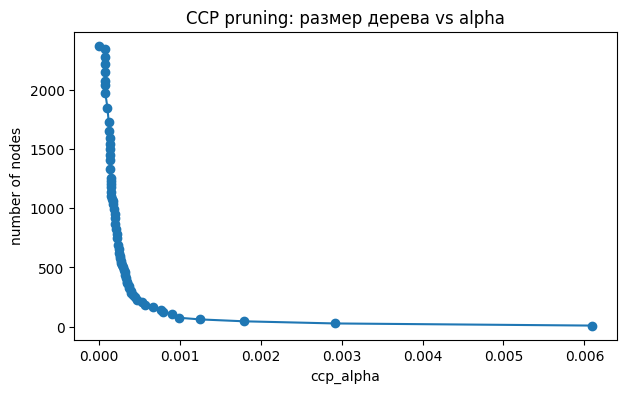

Decision Tree - best: 
{'accuracy': 0.8462222222222222, 'precision': 0.7474747474747475, 'recall': 0.626057529610829, 'F1 score': 0.6813996316758748, 'roc_auc': 0.815035202540825}


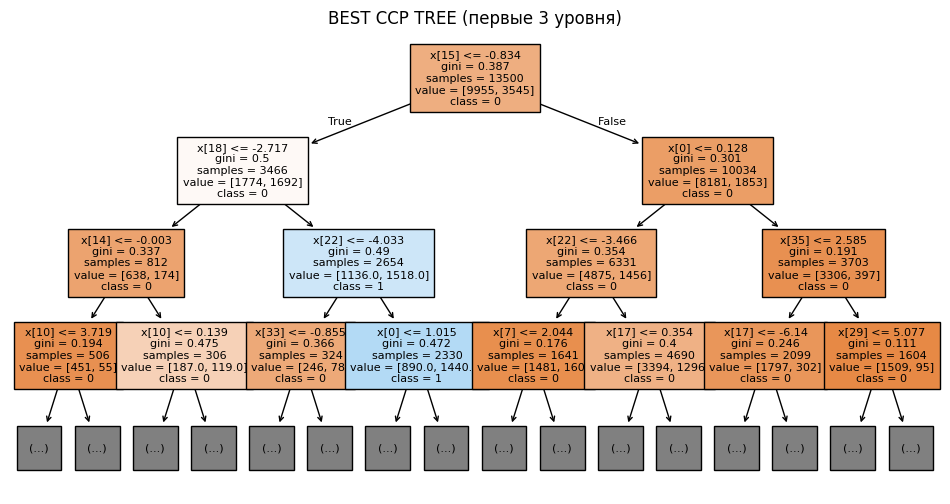

In [133]:
# DecesionTree 
tree_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_full.fit(X_train, y_train)

path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

ccp_alphas = np.unique(ccp_alphas)
if len(ccp_alphas) > 60:
    ccp_alphas = ccp_alphas[:: max(1, len(ccp_alphas)//60)]
    
train_scores = []
test_scores = []
node_counts = []

models = []

for a in ccp_alphas:
    model = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=float(a))
    model.fit(X_train, y_train)
    models.append(model)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))
    node_counts.append(model.tree_.node_count)
    
best_idx = int(np.argmax(test_scores))
best_alpha = float(ccp_alphas[best_idx])
best_model = models[best_idx]

print(f"Лучший alpha по test accuracy: {best_alpha}")
# Показываю как меняется размер дерева со сложностью альфы 
plt.figure(figsize=(7, 4))
plt.plot(ccp_alphas, node_counts, marker="o")
plt.xlabel("ccp_alpha")
plt.ylabel("number of nodes")
plt.title("CCP pruning: размер дерева vs alpha")
plt.show()

    
metrics_ccp_tree = calculate_metrics(y_test, best_model.predict(X_test), best_model.predict_proba(X_test)[:, 1])

metrics_all["Decision Tree"] = metrics_ccp_tree
print(f"Decision Tree - best: \n{metrics_ccp_tree}")

with open('./artifacts/metrics_ccp_tree.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_ccp_tree, f, indent=2, ensure_ascii=False)
    
plt.figure(figsize=(12, 6))
plot_tree(best_model, max_depth=3, 
          filled=True, 
          class_names=["0", "1"], 
          fontsize=8, 
          )
plt.title("BEST CCP TREE (первые 3 уровня)")
plt.savefig("./artifacts/figures/best_ccp_tree.png", dpi=150, bbox_inches="tight")
plt.show()

## Ансамбль типа беггинг (bootstrap), случайный лес 

Random Forest, oob score = 0.8950
{'accuracy': 0.8968888888888888, 'precision': 0.9174418604651163, 'recall': 0.6675126903553299, 'F1 score': 0.7727717923604309, 'roc_auc': 0.9284014843916534}


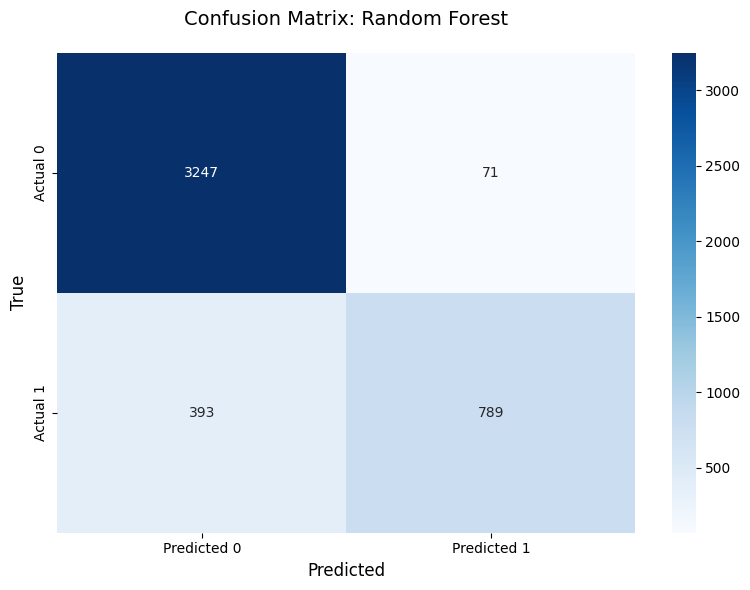

In [137]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.inspection import permutation_importance

rf = RandomForestClassifier(
    n_estimators=400, 
    random_state=RANDOM_STATE, 
    oob_score=True, 
    n_jobs=1, 
    max_features=10, 
)

rf.fit(X_train, y_train)

print(f"Random Forest, oob score = {rf.oob_score_:.4f}")
random_forest_metrics = calculate_metrics(y_test, y_pred=rf.predict(X_test), y_proba=rf.predict_proba(X_test)[:,1])
print(random_forest_metrics)
metrics_all["Random Forest"] = random_forest_metrics 
with open('./artifacts/random_forest_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(random_forest_metrics, f, indent=2, ensure_ascii=False)



## AdaBoost

In [ ]:
stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)

ada = AdaBoostClassifier(
    estimator=stump, 
    n_estimators=500,
    learning_rate=0.6,
    random_state=RANDOM_STATE
)

ada.fit(X_test, y_test)
ada_metrics = calculate_metrics(y_test, ada.predict(X_test), ada.predict_proba(X_test)[:, 1])

metrics_all["AdaBoost"] = ada_metrics
print(ada_metrics)

{'accuracy': 0.8395555555555556, 'precision': 0.8176795580110497, 'F1 score': 0.621196222455404, 'roc_auc': 0.8743769563341626}


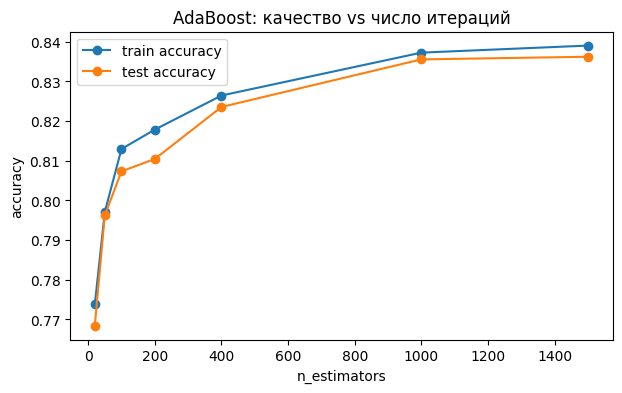

In [ ]:
n_estimators_grid = [20, 50, 100, 200, 400, 1000, 1500]
train_acc = []
test_acc = []


for n_est in n_estimators_grid:
    model = AdaBoostClassifier(estimator=stump, n_estimators=n_est, learning_rate=0.6, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(7, 4))
plt.plot(n_estimators_grid, train_acc, marker="o", label="train accuracy")
plt.plot(n_estimators_grid, test_acc, marker="o", label="test accuracy")
plt.xlabel("n_estimators")
plt.ylabel("accuracy")
plt.title("AdaBoost: качество vs число итераций")
plt.legend()
plt.show()

## Стекинг 

In [138]:

# создаем массив из 3 базовых моделей 
estimators = [
    ('lr', Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=2000))])),
    ('rf', RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=250, learning_rate=0.05, max_depth=2, random_state=RANDOM_STATE)),
]


final_est = LogisticRegression(max_iter=2000)

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=final_est,
    cv=5,
    n_jobs=-1,
    passthrough=False
)

stack.fit(X_train, y_train)

stack_metrics = calculate_metrics(y_test, stack.predict(X_test), stack.predict_proba(X_test)[:, 1])
metrics_all["Stacking"] = stack_metrics
print(stack_metrics)

{'accuracy': 0.9135555555555556, 'precision': 0.8838334946757018, 'recall': 0.772419627749577, 'F1 score': 0.8243792325056434, 'roc_auc': 0.9325450371199904}


                     accuracy  precision    recall  F1 score   roc_auc
Dummy Stratified     0.618000   0.267532  0.261421  0.264442  0.503224
Logistic Regression  0.816222   0.736983  0.467005  0.571724  0.800890
Decision Tree        0.846222   0.747475  0.626058  0.681400  0.815035
Random Forest        0.896889   0.917442  0.667513  0.772772  0.928401
Stacking             0.913556   0.883833  0.772420  0.824379  0.932545


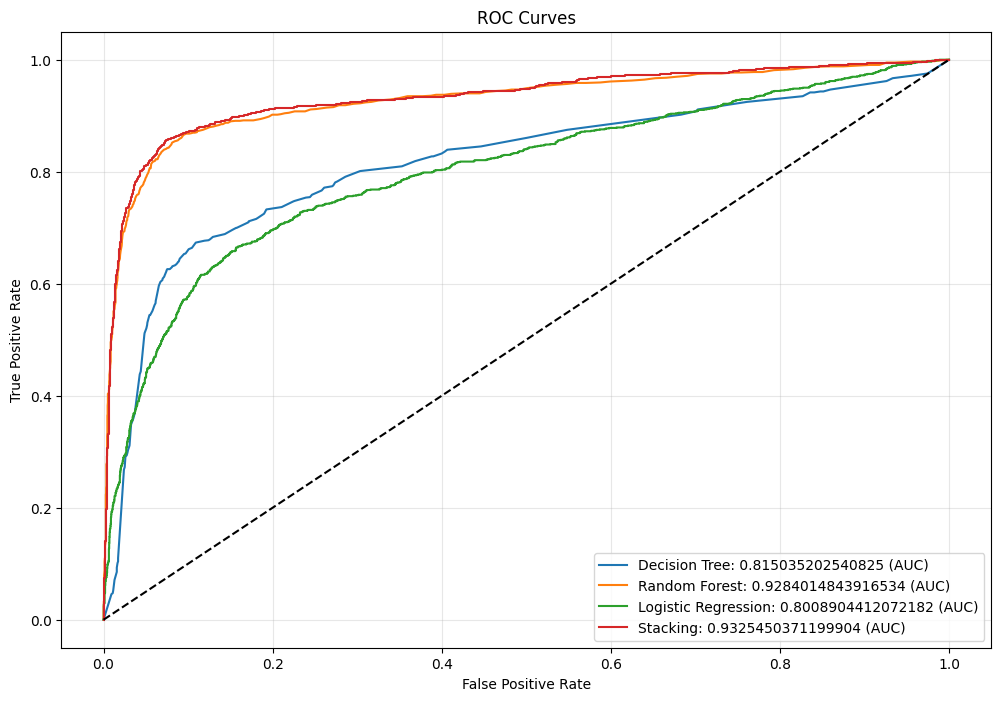

Лучшая модель по roc_auc: Stacking


In [140]:
metrics_df = pd.DataFrame(metrics_all).T
print(metrics_df)

models = {
    "Decision Tree": best_model, 
    "Random Forest": rf,
    "Logistic Regression": pipe_lr,
    "Stacking": stack
}

plt.figure(figsize=(12,8))

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name}: {auc_score} (AUC)")
        

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('./artifacts/figures/ROC-curve.png', dpi=300, bbox_inches='tight')
plt.show()


best_model_name = metrics_df['roc_auc'].idxmax()
print(f'Лучшая модель по roc_auc: {best_model_name}')


Permutation Importance для Stacking:

15 важных признаков:
   feature  importance_mean  importance_std
15     f16           0.0424        0.005886
0      f01           0.0212        0.002135
11     f12           0.0176        0.003200
6      f07           0.0132        0.005115
22     f23           0.0128        0.002482
12     f13           0.0112        0.002786
17     f18           0.0112        0.001166
4      f05           0.0110        0.002608
28     f29           0.0104        0.001356
7      f08           0.0096        0.001020
29     f30           0.0082        0.003655
3      f04           0.0080        0.003795
32     f33           0.0076        0.001497
1      f02           0.0074        0.002728
18     f19           0.0074        0.003137


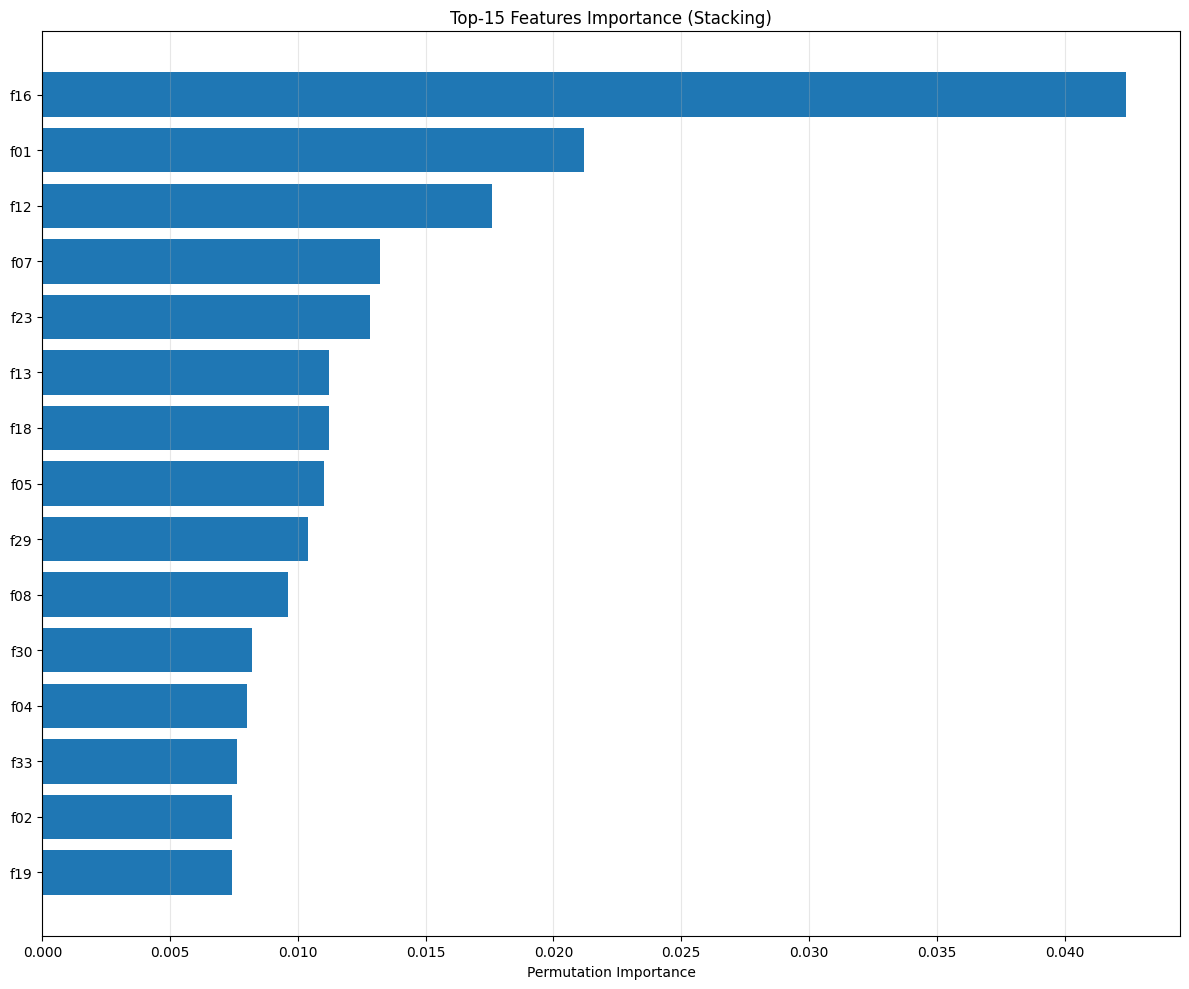

In [141]:

print(f"\nPermutation Importance для {best_model_name}:")
if len(X_test) > 1000:
    sample_idx = np.random.choice(len(X_test), 1000, replace=False)
    X_test_sample = X_test.iloc[sample_idx]
    y_test_sample = y_test.iloc[sample_idx]
else:
    X_test_sample, y_test_sample = X_test, y_test

res = permutation_importance(
    stack, X_test_sample, y_test_sample,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': res.importances_mean,
    'importance_std': res.importances_std
}).sort_values('importance_mean', ascending=False)

print("\n15 важных признаков:")
print(importance_df.head(15))

plt.figure(figsize=(12, 10))
top_n = min(15, len(importance_df))
top_features = importance_df.head(top_n)
plt.barh(range(top_n), top_features['importance_mean'][::-1])
plt.yticks(range(top_n), top_features['feature'][::-1])
plt.xlabel('Permutation Importance')
plt.title(f'Top-{top_n} Features Importance ({best_model_name})')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig("artifacts/figures/feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

In [116]:
random_forest_meta = {
    "model_name": best_model_name, 
    "test_metrics": random_forest_metrics,
    "top_features": importance_df.head(15).to_dict('records'),
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "random_state": RANDOM_STATE,
    "test_size": 0.25,
    "dataset": "S06-hw-dataset-02.csv"
}

with open('artifacts/best_model_meta.json', 'w') as f:
    json.dump(random_forest_meta, f, indent=2)

In [118]:
try: 
    joblib.dump(rf, './artifacts/figures/best_model.joblib')
except Exception as e:
    print(f"Ошибка при сохранении модели: {e}")

In [127]:
print(metrics_df)

                     accuracy  precision    recall  F1 score   roc_auc
Dummy Stratified     0.618000   0.267532  0.261421  0.264442  0.503224
Logistic Regression  0.816222   0.736983  0.467005  0.571724  0.800890
Decision Tree        0.846222   0.747475  0.626058  0.681400  0.815035
Random Forest        0.896889   0.917442  0.667513  0.772772  0.928401


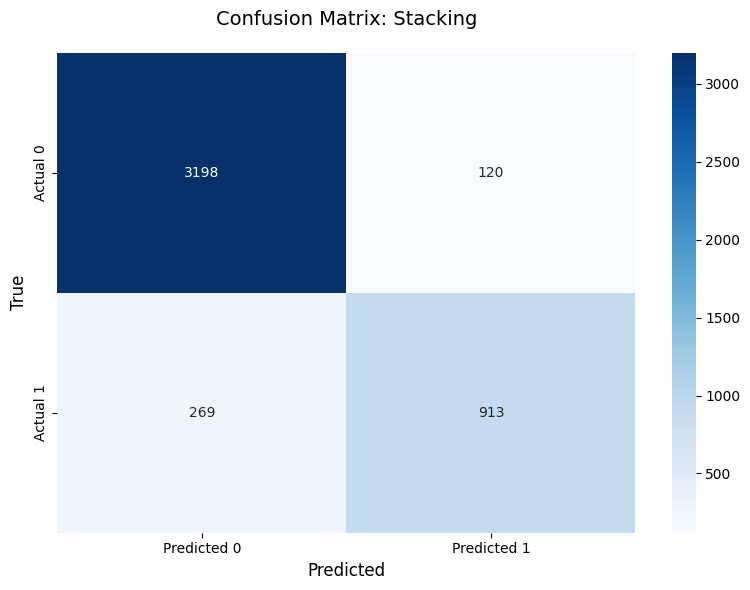

In [142]:
def plot_confusion_matrix_heatmap(y_true, y_pred, model_name="Model"):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix: {model_name}', fontsize=14, pad=20)
    plt.ylabel('True', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    plt.tight_layout()
    
    plt.savefig('./artifacts/figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    return cm

stack_cm = plot_confusion_matrix_heatmap(y_test, y_pred=stack.predict(X_test), model_name="Stacking")